In [69]:
## SENSITIVITY ANALYSIS ON DEMOGRAPHIC VS ANXIETY_SCORE

## METHOD
## A threshold sensitivity analysis was conducted by dichotomizing the continuous GAD-7 score at a sequence of cut-off values from 5 to 15.
## For each threshold t, a binary outcome variable was defined as I(score≥t). 
## Associations between demographic variables and threshold-defined anxiety status were then evaluated repeatedly across cut-offs using 
## logistic regression and complementary chi-square tests. Stability of associations was assessed by examining the consistency of 
## effect direction, odds ratios, confidence intervals, and significance patterns across thresholds.
## The analysis was conducted at the participant level, with each record representing one independent respondent.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install statsmodels
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

In [12]:
df = pd.read_csv("C:/Users/liang/Desktop/Work/Project/GAD7/GAD7_clean.csv")
df.head()

,id,score,type1,age,gender,marriage,education,occupation,income,q40,...,q580_1,q580_2,q580_3,q580_4,q580_5,q580_6,q580_7,q580_8,q580_9,age_group
0,1,6,0,26,1,0,4,0.0,3,1,...,1,0,0,0,0,0,0,0,0,25-34
1,2,7,3,36,1,2,5,1.0,2,3,...,0,0,0,0,0,0,0,0,0,35-44
2,3,13,7,11,0,0,2,12.0,0,1,...,0,0,0,0,0,0,0,0,0,<15
3,4,8,0,10,1,0,1,12.0,0,2,...,0,0,0,0,0,0,0,0,0,<15
4,5,6,0,10,1,0,1,12.0,0,1,...,0,0,0,0,0,0,0,0,0,<15


In [70]:
# 1. ANXIETY_SCORE VS GENDER
gender_df = df[['score', 'gender']].copy()

gender_df['gender'] = gender_df['gender'].replace({
    0: 'male',
    1: 'female',
    '0': 'male',
    '1': 'female'
})

In [71]:
## Threshold Sensitivity
thresholds = range(5, 16)

result_list = []

for t in thresholds:
    temp = gender_df.copy()
    temp['high_anxiety'] = (temp['score'] >= t).astype(int)

    summary = (
        temp.groupby('gender')['high_anxiety']
        .agg(['count', 'sum', 'mean'])
        .reset_index()
        .rename(columns={
            'count': 'n',
            'sum': 'high_n',
            'mean': 'high_rate'
        })
    )

    summary['threshold'] = t
    result_list.append(summary)

result_long = pd.concat(result_list, ignore_index=True)
result_long['high_rate_pct'] = result_long['high_rate'] * 100

print(result_long.head(10))

result_wide = result_long.pivot(
    index='threshold',
    columns='gender',
    values='high_rate_pct'
).reset_index()

result_wide['gap_female_minus_male'] = result_wide['female'] - result_wide['male']

print(result_wide)


   gender      n  high_n  high_rate  threshold  high_rate_pct
0  female  20918   15691   0.750120          5      75.011951
1    male   9082    5921   0.651949          5      65.194891
2  female  20918   14181   0.677933          6      67.793288
3    male   9082    5349   0.588967          6      58.896719
4  female  20918   12541   0.599532          7      59.953150
5    male   9082    4724   0.520150          7      52.014975
6  female  20918   10758   0.514294          8      51.429391
7    male   9082    3914   0.430962          8      43.096234
8  female  20918    9502   0.454250          9      45.424993
9    male   9082    3456   0.380533          9      38.053292
gender  threshold     female       male  gap_female_minus_male
0               5  75.011951  65.194891               9.817060
1               6  67.793288  58.896719               8.896569
2               7  59.953150  52.014975               7.938176
3               8  51.429391  43.096234               8.333157
4  

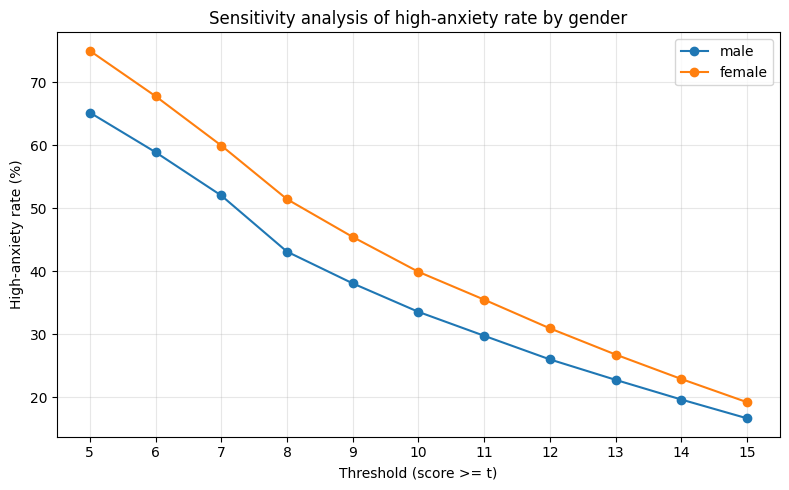

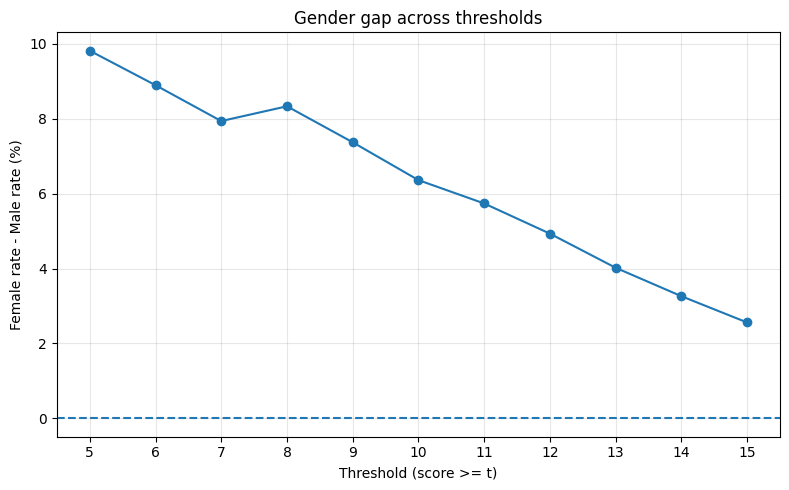

In [72]:
## Visualize

# MALE/FEMALE RATE
plt.figure(figsize=(8, 5))

for g in ['male', 'female']:
    sub = result_long[result_long['gender'] == g]
    plt.plot(sub['threshold'], sub['high_rate_pct'], marker='o', label=g)

plt.xlabel('Threshold (score >= t)')
plt.ylabel('High-anxiety rate (%)')
plt.title('Sensitivity analysis of high-anxiety rate by gender')
plt.xticks(list(thresholds))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GENDER GAP
plt.figure(figsize=(8, 5))

plt.plot(
    result_wide['threshold'],
    result_wide['gap_female_minus_male'],
    marker='o'
)

plt.axhline(y=0, linestyle='--')
plt.xlabel('Threshold (score >= t)')
plt.ylabel('Female rate - Male rate (%)')
plt.title('Gender gap across thresholds')
plt.xticks(list(thresholds))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
### RESULT
## Across all thresholds, females consistently showed a higher high-anxiety rate than males.
## As the threshold increased, the proportion of high-anxiety participants declined in both groups, 
## but the gender difference remained positive throughout.

## Intrepretation
## The sensitivity analysis suggests that the association between gender and GAD-7 severity is relatively robust to threshold choice.
## Female participants were more likely than male participants to fall above the anxiety threshold at every cut-off examined， 
## indicating that the observed gender pattern is not dependent on a single arbitrary threshold。

In [41]:
# 2. ANXIETY_SCORE VS AGE(Group)
age_df = df[['score', 'age_group']].copy()

age_order = ['<15', '15-19', '20-24', '25-34', '35-44', '45+']

age_df = age_df[age_df['age_group'].isin(age_order)].copy()
age_df['age_group'] = pd.Categorical(age_df['age_group'], categories=age_order, ordered=True)

In [42]:
## Threshold Sensitivity
thresholds = range(5, 16)

result_list = []

for t in thresholds:
    temp = age_df.copy()
    temp['high_anxiety'] = (temp['score'] >= t).astype(int)

    summary = (
        temp.groupby('age_group', observed=False)['high_anxiety']
        .agg(['count', 'sum', 'mean'])
        .reset_index()
        .rename(columns={
            'count': 'n',
            'sum': 'high_n',
            'mean': 'high_rate'
        })
    )

    summary['threshold'] = t
    result_list.append(summary)

age_result_long = pd.concat(result_list, ignore_index=True)
age_result_long['high_rate_pct'] = age_result_long['high_rate'] * 100

print(age_result_long.head(15))

   age_group     n  high_n  high_rate  threshold  high_rate_pct
0        <15   743     603   0.811575          5      81.157470
1      15-19  5640    4560   0.808511          5      80.851064
2      20-24  8483    6680   0.787457          5      78.745727
3      25-34  8722    6226   0.713827          5      71.382710
4      35-44  3794    2315   0.610174          5      61.017396
5        45+  1003     533   0.531406          5      53.140578
6        <15   743     573   0.771198          6      77.119785
7      15-19  5640    4202   0.745035          6      74.503546
8      20-24  8483    6122   0.721679          6      72.167865
9      25-34  8722    5594   0.641367          6      64.136666
10     35-44  3794    1996   0.526094          6      52.609383
11       45+  1003     441   0.439681          6      43.968096
12       <15   743     539   0.725437          7      72.543742
13     15-19  5640    3811   0.675709          7      67.570922
14     20-24  8483    5490   0.647177   

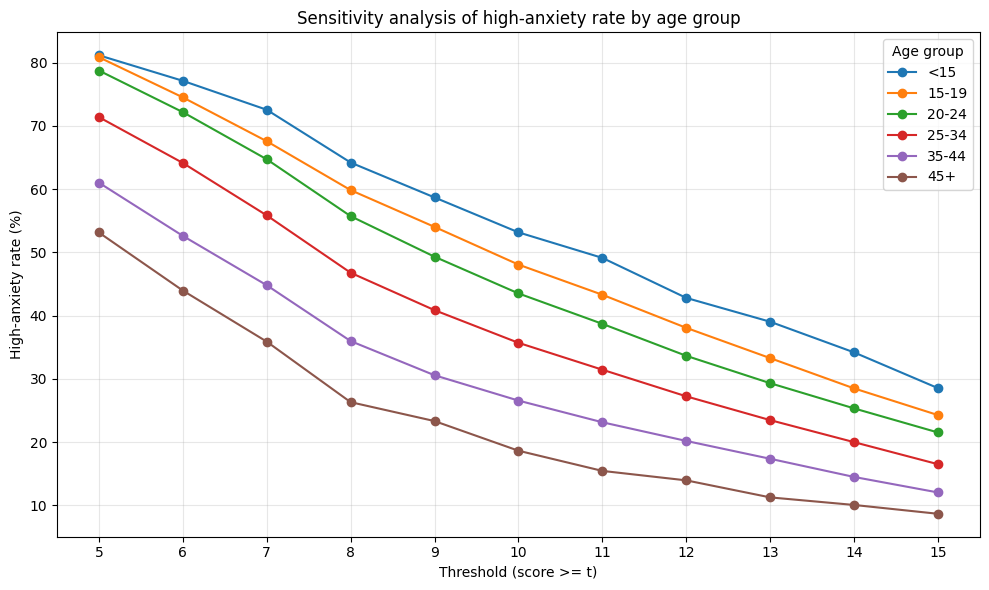

In [44]:
## Visualize
age_result_wide = age_result_long.pivot(
    index='threshold',
    columns='age_group',
    values='high_rate_pct'
).reset_index()

plt.figure(figsize=(10, 6))

for group in age_order:
    sub = age_result_long[age_result_long['age_group'] == group]
    plt.plot(sub['threshold'], sub['high_rate_pct'], marker='o', label=group)

plt.xlabel('Threshold (score >= t)')
plt.ylabel('High-anxiety rate (%)')
plt.title('Sensitivity analysis of high-anxiety rate by age group')
plt.xticks(list(thresholds))
plt.legend(title='Age group')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
### RESULT 
## Across all thresholds, younger age groups consistently showed higher high-anxiety rates than older age groups.
## As the threshold increased, the proportion of high-anxiety participants declined in every age group, 
## but the overall age gradient remained stable throughout.

## Interpretation
## The sensitivity analysis suggests that the association between age and GAD-7 severity is robust to threshold choice.
## Younger participants were consistently more likely to fall above the anxiety threshold, 
## indicating that the observed age pattern was not dependent on a single arbitrary cut-off.

In [48]:
# 3. ANXIETY_SCORE VS EDUCATION BACKGROUND
edu_df = df[['score', 'education']].copy()

edu_map = {
    0: 'Primary',
    1: 'Middle School',
    2: 'High School',
    3: 'College',
    4: 'University',
    5: 'Master',
    6: 'Doctorate'
}

edu_df['education_group'] = edu_df['education'].map(edu_map)

edu_order = [
    'Primary',
    'Middle School',
    'High School',
    'College',
    'University',
    'Master',
    'Doctorate'
]

edu_df = edu_df[edu_df['education_group'].isin(edu_order)].copy()
edu_df['education_group'] = pd.Categorical(
    edu_df['education_group'],
    categories=edu_order,
    ordered=True
)

In [49]:
## Threshold Sensitivity
thresholds = range(5, 16)

edu_result_list = []

for t in thresholds:
    temp = edu_df.copy()
    temp['high_anxiety'] = (temp['score'] >= t).astype(int)

    summary = (
        temp.groupby('education_group', observed=False)['high_anxiety']
        .agg(['count', 'sum', 'mean'])
        .reset_index()
        .rename(columns={
            'count': 'n',
            'sum': 'high_n',
            'mean': 'high_rate'
        })
    )

    summary['threshold'] = t
    edu_result_list.append(summary)

edu_result_long = pd.concat(edu_result_list, ignore_index=True)
edu_result_long['high_rate_pct'] = edu_result_long['high_rate'] * 100

print(edu_result_long.head(15))

   education_group     n  high_n  high_rate  threshold  high_rate_pct
0          Primary   697     518   0.743185          5      74.318508
1    Middle School  4609    3570   0.774571          5      77.457149
2      High School  5777    4358   0.754371          5      75.437078
3          College  8065    5865   0.727216          5      72.721637
4       University  9252    6325   0.683636          5      68.363597
5           Master  1450     888   0.612414          5      61.241379
6        Doctorate   150      88   0.586667          5      58.666667
7          Primary   697     482   0.691535          6      69.153515
8    Middle School  4609    3303   0.716641          6      71.664135
9      High School  5777    3978   0.688593          6      68.859270
10         College  8065    5311   0.658524          6      65.852449
11      University  9252    5618   0.607220          6      60.722006
12          Master  1450     760   0.524138          6      52.413793
13       Doctorate  

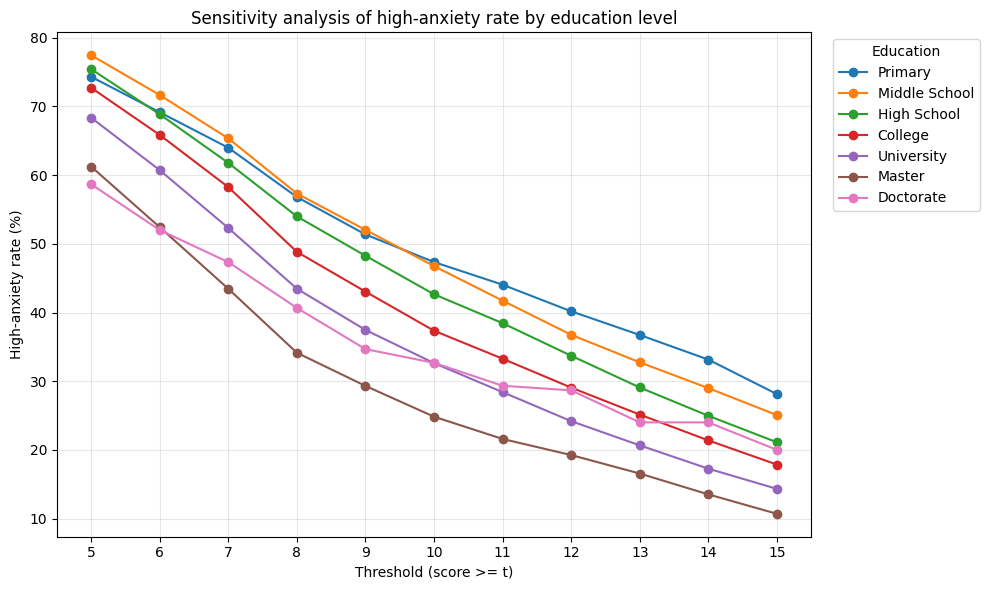

In [52]:
## Visualize
edu_result_wide = edu_result_long.pivot(
    index='threshold',
    columns='education_group',
    values='high_rate_pct'
).reset_index()

plt.figure(figsize=(10, 6))

for group in edu_order:
    sub = edu_result_long[edu_result_long['education_group'] == group]
    plt.plot(sub['threshold'], sub['high_rate_pct'], marker='o', label=group)

plt.xlabel('Threshold (score >= t)')
plt.ylabel('High-anxiety rate (%)')
plt.title('Sensitivity analysis of high-anxiety rate by education level')
plt.xticks(list(thresholds))
plt.legend(title='Education', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
### Result
## Across all thresholds, the Middle School, High School, and Primary groups tended to show the highest high-anxiety rates,
## whereas the Master and Doctorate groups generally showed the lowest rates.
## Although high-anxiety rates decreased as the threshold increased, the relative ordering across education groups remained broadly similar.

## Interpretation
## These results suggest a broadly stable education gradient in GAD-7 severity.
## Lower educational attainment was generally associated with a higher anxiety burden,
## while higher educational attainment was associated with lower threshold-defined anxiety across the examined cut-offs.

In [54]:
# 4. ANXIETY_SCORE VS INCOME_LEVEL
inc_df = df[['score', 'income']].copy()

income_map = {
    0: '0-50k',
    1: '50-100k',
    2: '100-200k',
    3: '200-400k',
    4: '400-800k',
    5: '800k+'
}

inc_order = ['0-50k', '50-100k', '100-200k', '200-400k', '400-800k', '800k+']

inc_df['income_group'] = inc_df['income'].map(income_map)
inc_df = inc_df[inc_df['income_group'].isin(inc_order)].copy()
inc_df['income_group'] = pd.Categorical(
    inc_df['income_group'],
    categories=inc_order,
    ordered=True
)

In [57]:
## Threshold Sensitivity
thresholds = range(5, 16)

inc_result_list = []

for t in thresholds:
    temp = inc_df.copy()
    temp['high_anxiety'] = (temp['score'] >= t).astype(int)

    summary = (
        temp.groupby('income_group', observed=False)['high_anxiety']
        .agg(['count', 'sum', 'mean'])
        .reset_index()
        .rename(columns={
            'count': 'n',
            'sum': 'high_n',
            'mean': 'high_rate'
        })
    )

    summary['threshold'] = t
    inc_result_list.append(summary)

inc_result_long = pd.concat(inc_result_list, ignore_index=True)
inc_result_long['high_rate_pct'] = inc_result_long['high_rate'] * 100

print(inc_result_long.head(15))

   income_group      n  high_n  high_rate  threshold  high_rate_pct
0         0-50k  15370   11848   0.770852          5      77.085231
1       50-100k   9275    6434   0.693693          5      69.369272
2      100-200k   3695    2334   0.631664          5      63.166441
3      200-400k   1152     685   0.594618          5      59.461806
4      400-800k    289     171   0.591696          5      59.169550
5         800k+    219     140   0.639269          5      63.926941
6         0-50k  15370   10887   0.708328          6      70.832791
7       50-100k   9275    5729   0.617682          6      61.768194
8      100-200k   3695    2037   0.551286          6      55.128552
9      200-400k   1152     600   0.520833          6      52.083333
10     400-800k    289     153   0.529412          6      52.941176
11        800k+    219     124   0.566210          6      56.621005
12        0-50k  15370    9813   0.638452          7      63.845153
13      50-100k   9275    4956   0.534340       

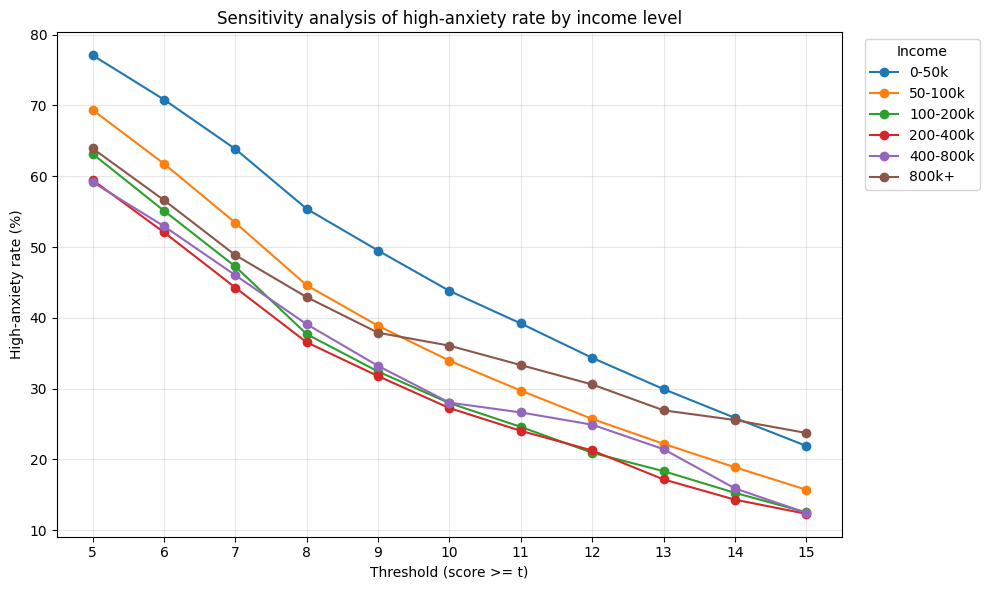

In [58]:
## Visualize
inc_result_wide = inc_result_long.pivot(
    index='threshold',
    columns='income_group',
    values='high_rate_pct'
).reset_index()

plt.figure(figsize=(10, 6))

for group in inc_order:
    sub = inc_result_long[inc_result_long['income_group'] == group]
    plt.plot(sub['threshold'], sub['high_rate_pct'], marker='o', label=group)

plt.xlabel('Threshold (score >= t)')
plt.ylabel('High-anxiety rate (%)')
plt.title('Sensitivity analysis of high-anxiety rate by income level')
plt.xticks(list(thresholds))
plt.legend(title='Income', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
### Result
## Across all thresholds, the 0–50k income group showed the highest high-anxiety rate. 
## In general, high-anxiety rates tended to decline as income increased, 
## although the 800k+ group did not fully follow a monotonic pattern, especially at higher thresholds.
## Patterns for the highest-income groups should be interpreted cautiously because of their relatively small sample sizes.

## Interpretation
## These results suggest a broadly stable inverse relationship between income and GAD-7 severity.
## Participants in lower-income groups consistently exhibited a greater anxiety burden,
## while the pattern among the highest-income groups appeared less stable, likely reflecting smaller subgroup sizes.

In [62]:
# 5. ANXIETY_SCORE VS MARRIAGE
mar_df = df[['score', 'marriage']].copy()

marriage_map = {
    0: 'Single',
    1: 'Cohabit',
    2: 'Married',
    3: 'Divorced/Widowed',
    4: 'Divorced/Widowed'
}

mar_order = ['Single', 'Cohabit', 'Married', 'Divorced/Widowed']

mar_df['marriage_group'] = mar_df['marriage'].map(marriage_map)
mar_df = mar_df[mar_df['marriage_group'].isin(mar_order)].copy()
mar_df['marriage_group'] = pd.Categorical(
    mar_df['marriage_group'],
    categories=mar_order,
    ordered=True
)

In [64]:
## Threshold Sensitivity
thresholds = range(5, 16)

mar_result_list = []

for t in thresholds:
    temp = mar_df.copy()
    temp['high_anxiety'] = (temp['score'] >= t).astype(int)

    summary = (
        temp.groupby('marriage_group', observed=False)['high_anxiety']
        .agg(['count', 'sum', 'mean'])
        .reset_index()
        .rename(columns={
            'count': 'n',
            'sum': 'high_n',
            'mean': 'high_rate'
        })
    )

    summary['threshold'] = t
    mar_result_list.append(summary)

mar_result_long = pd.concat(mar_result_list, ignore_index=True)
mar_result_long['high_rate_pct'] = mar_result_long['high_rate'] * 100

print(mar_result_long.head(20))

      marriage_group      n  high_n  high_rate  threshold  high_rate_pct
0             Single  15401   11961   0.776638          5      77.663788
1            Cohabit   1468    1196   0.814714          5      81.471390
2            Married  11848    7536   0.636057          5      63.605672
3   Divorced/Widowed   1283     919   0.716290          5      71.628995
4             Single  15401   10959   0.711577          6      71.157717
5            Cohabit   1468    1089   0.741826          6      74.182561
6            Married  11848    6634   0.559926          6      55.992573
7   Divorced/Widowed   1283     848   0.660951          6      66.095090
8             Single  15401    9841   0.638984          7      63.898448
9            Cohabit   1468     997   0.679155          7      67.915531
10           Married  11848    5668   0.478393          7      47.839298
11  Divorced/Widowed   1283     759   0.591582          7      59.158223
12            Single  15401    8507   0.552367     

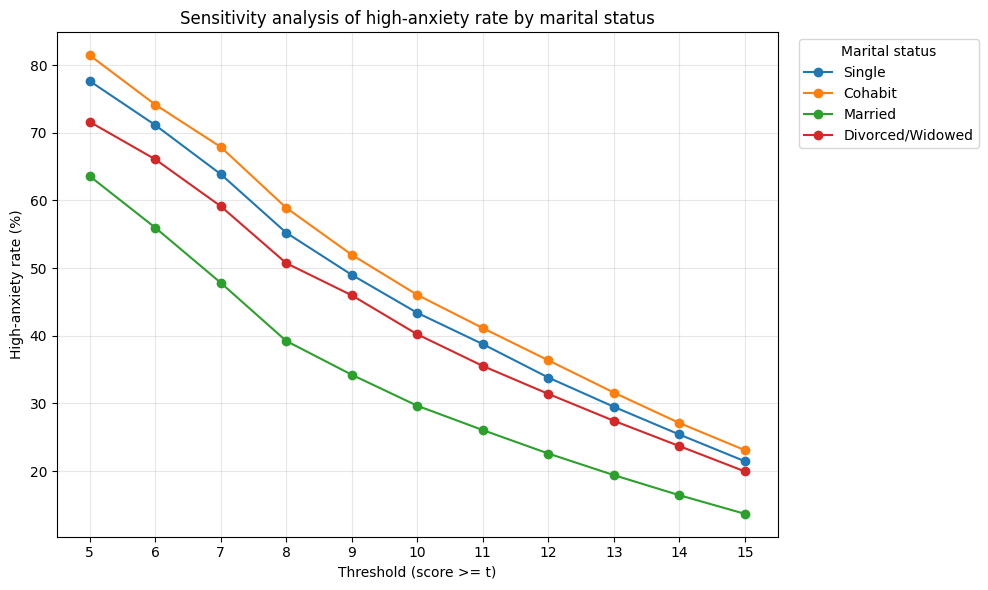

In [65]:
## Visualize
mar_result_wide = mar_result_long.pivot(
    index='threshold',
    columns='marriage_group',
    values='high_rate_pct'
).reset_index()

plt.figure(figsize=(10, 6))

for group in mar_order:
    sub = mar_result_long[mar_result_long['marriage_group'] == group]
    plt.plot(sub['threshold'], sub['high_rate_pct'], marker='o', label=group)

plt.xlabel('Threshold (score >= t)')
plt.ylabel('High-anxiety rate (%)')
plt.title('Sensitivity analysis of high-anxiety rate by marital status')
plt.xticks(list(thresholds))
plt.legend(title='Marital status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
### Result
## Across all thresholds, Cohabit and Single participants had higher high-anxiety rates than Married participants,
## while the Divorced/Widowed group remained intermediate.
## Although high-anxiety rates declined as the threshold increased,
## the relative ordering across marital-status groups remained broadly unchanged.

## Interpretation
## These results suggest a stable association between marital status and GAD-7 severity.
## Married participants consistently showed a lower anxiety burden, 
## while cohabiting and single participants were more likely to fall above the anxiety threshold across the full threshold range.

In [68]:
# Overall Summarize
##| Variable       | Main pattern across thresholds     | Stability      |
##| -------------- | ---------------------------------- | -------------- |
##| Gender         | Female > Male                      | Stable         |
##| Age group      | Younger > Older                    | Stable         |
##| Education      | Lower education > Higher education | Broadly stable |
##| Income         | Lower income > Higher income       | Broadly stable |
##| Marital status | Cohabit/Single > Married           | Stable         |

## Result
## Overall, the threshold sensitivity analysis showed that the main demographic patterns remained broadly consistent across GAD-7 cut-offs from 5 to 15.
## Female participants consistently showed higher high-anxiety rates than males, younger age groups showed higher rates than older age groups, 
## and participants with lower education or lower income generally exhibited a greater anxiety burden.
## Similarly, cohabiting and single participants tended to show higher high-anxiety rates than married participants.
## Although the proportion of high-anxiety participants declined in all groups as the threshold increased, 
## the relative group ordering remained largely stable across thresholds.

## Interpretation
## These findings suggest that the associations between demographic characteristics and GAD-7 severity were generally robust to threshold choice.
## In other words, the observed patterns were not driven by a single arbitrary cut-off, but persisted across a range of threshold definitions.
## This supports the conclusion that gender, age, education, income, and marital status are meaningfully associated with anxiety burden in the sample, 
## although some subgroup-specific variation remained, particularly in categories with smaller sample sizes.